## STEP 1 — Dataset Load & Initial Diagnostics

In [1]:
import pandas as pd
import numpy as np

In [17]:
# Load dataset
df = pd.read_csv("netflix_titles.csv")

In [18]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [20]:
# Shape (rows, columns)
print("Shape:", df.shape)

Shape: (8807, 12)


In [21]:
# Info about dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [22]:
# Statistical summary
print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


## STEP 2 — Missing Values Analysis

In [25]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percent
})

print(missing_table)


              Missing Values  Percentage (%)
show_id                    0        0.000000
type                       0        0.000000
title                      0        0.000000
director                2634       29.908028
cast                     825        9.367549
country                  831        9.435676
date_added                10        0.113546
release_year               0        0.000000
rating                     4        0.045418
duration                   3        0.034064
listed_in                  0        0.000000
description                0        0.000000


## STEP 3 — Missing Values Visualization

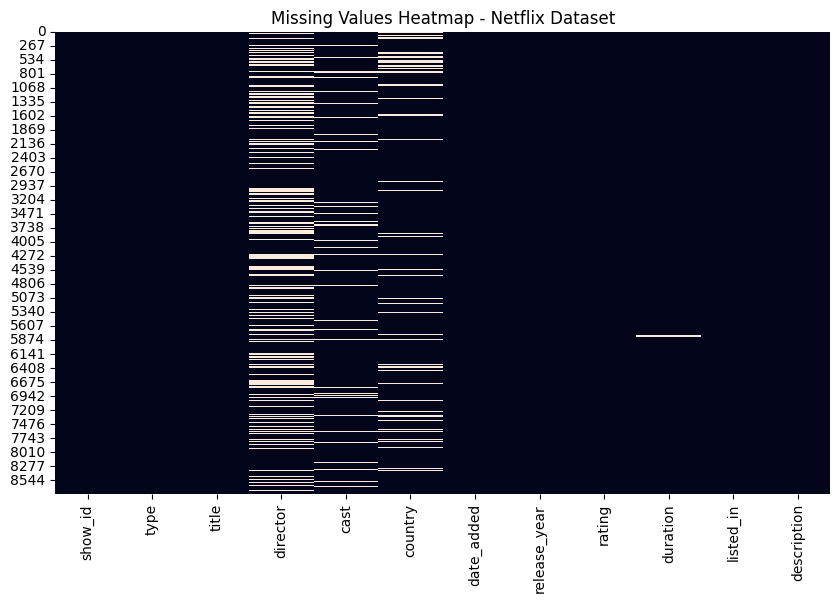

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap - Netflix Dataset")
plt.show()


## STEP 4  Data Type Correction & Date Parsing

In [27]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
print(df['date_added'].dtype)


datetime64[ns]


In [28]:
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')


## STEP 5 — Missing Values Imputation (2 Techniques)

### Technique 1: Mode Imputation (Categorical columns)

In [38]:
for col in ['director', 'cast', 'country', 'rating']:
    df[col] = df[col].fillna(df[col].mode()[0])


### Technique 2: Forward Fill (ffill)

In [39]:
df['date_added'] = df['date_added'].ffill()


### Numeric Column Imputation (Duration cleaning)

In [40]:
df['duration_num'] = df['duration_num'].fillna(df['duration_num'].median())


## STEP 6 — Duplicate Rows Check and Remove

In [32]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


##  STEP 7 — Outlier Detection (IQR Method)

In [33]:
Q1 = df['duration_num'].quantile(0.25)
Q3 = df['duration_num'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

df = df[(df['duration_num'] >= lower_bound) & (df['duration_num'] <= upper_bound)]


Lower Bound: -154.0
Upper Bound: 262.0


## STEP 8 — Text Cleaning

In [34]:
df['title'] = df['title'].str.strip()
df['type'] = df['type'].str.strip()


## STEP 9 — Before vs After Comparison

In [35]:
df_before = pd.read_csv("netflix_titles.csv")

print("Before Cleaning Shape:", df_before.shape)
print("After Cleaning Shape:", df.shape)

print("\nBefore Sample Data:")
print(df_before.head())

print("\nAfter Sample Data:")
print(df.head())


Before Cleaning Shape: (8807, 12)
After Cleaning Shape: (8805, 13)

Before Sample Data:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min  

## STEP 10 — Save Cleaned Dataset

In [36]:
df.to_csv("netflix_cleaned_dataset.csv", index=False)
print("✅ Cleaned dataset saved successfully!")


✅ Cleaned dataset saved successfully!


## STEP 11 — Log Transformations

In [37]:
transformations = [
    "Converted date_added to datetime",
    "Filled missing values using mode and forward fill",
    "Extracted numeric duration and filled missing values with median",
    "Removed duplicate rows",
    "Removed outliers using IQR method",
    "Cleaned text columns"
]

for t in transformations:
    print("-", t)


- Converted date_added to datetime
- Filled missing values using mode and forward fill
- Extracted numeric duration and filled missing values with median
- Removed duplicate rows
- Removed outliers using IQR method
- Cleaned text columns
